# Chapter 11: Value at Risk

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. Parametric normal VaR
2. Multi-day scaling and sign conventions
3. Normality tests and modified VaR
4. Historical VaR and expected shortfall
5. Portfolio VaR

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 11.1 Parametric One-Day and Ten-Day VaR

VaR is reported here as a positive loss amount. Under iid normal returns, volatility scales with the square root of time.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [1]:
import numpy as np
from scipy.stats import norm

rng = np.random.default_rng(1101)
returns = rng.normal(0.0004, 0.018, 1000)
position = 100_000
confidence = 0.99
z = norm.ppf(confidence)
mean, volatility = returns.mean(), returns.std(ddof=1)

# 左尾收益分位数为负；取负号后把 VaR 报告成正的损失金额
var_1_day = -position * (mean - z * volatility)
mean_10_day = (1 + mean) ** 10 - 1
var_10_day = -position * (mean_10_day - z * volatility * np.sqrt(10))

print("1-day VaR =", round(var_1_day, 2))
print("10-day VaR =", round(var_10_day, 2))


1-day VaR = 4007.62
10-day VaR = 12221.77


**Result interpretation.** Ten-day VaR is larger, but it is not exactly ten times one-day VaR because volatility uses square-root-of-time scaling.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 11.2 Normality and Modified VaR

Shapiro-Wilk tests normality. Cornish-Fisher modified VaR adjusts the normal quantile for skewness and excess kurtosis.


### Structured Review

- **Hypotheses:** Write the null and alternative before selecting a test.
- **Tail choice:** Determine whether the test is one-sided or two-sided.
- **Reference distribution:** Match the statistic with the normal, Student-t, F, or chi-square distribution.
- **Decision:** Compare either the p-value with alpha or the statistic with its critical value.

### Test Selection

| Question | Typical method |
|---|---|
| One mean versus a target | One-sample t-test |
| Two independent means | Pooled or Welch t-test |
| Equality of variances | F-test or Levene test |
| First-order residual autocorrelation | Durbin-Watson |
| Predictive content of lagged variables | Granger F-test |
| Normality | Shapiro-Wilk or Anderson-Darling |

### Exam Focus

- Use `alpha/2` in each tail of a two-sided test.
- Track degrees of freedom when calling `ppf`.
- State conclusions as evidence to reject or not reject the null hypothesis.

### Common Mistakes

- Saying that a large p-value proves the null hypothesis.
- Using a one-sided critical value for a two-sided interval.
- Interpreting Granger causality as structural or philosophical causation.


In [2]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(1102)
# t 分布产生较厚尾部，用于展示正态假设可能失效
returns = 0.0004 + 0.012 * rng.standard_t(df=5, size=900)
confidence = 0.99
position = 100_000
z = stats.norm.ppf(1 - confidence)

skewness = stats.skew(returns, bias=False)
excess_kurtosis = stats.kurtosis(returns, fisher=True, bias=False)
test = stats.shapiro(returns)

# Cornish-Fisher 展开修正左尾分位数
adjusted_z = (
    z
    + (z**2 - 1) * skewness / 6
    + (z**3 - 3 * z) * excess_kurtosis / 24
    - (2 * z**3 - 5 * z) * skewness**2 / 36
)
modified_var = -position * (returns.mean() + adjusted_z * returns.std(ddof=1))

print("Skewness =", round(float(skewness), 4))
print("Excess kurtosis =", round(float(excess_kurtosis), 4))
print("Shapiro p-value =", round(float(test.pvalue), 8))
print("Modified VaR =", round(float(modified_var), 2))


Skewness = -0.1008
Excess kurtosis = 2.5677
Shapiro p-value = 0.0
Modified VaR = 4523.26


**Result interpretation.** A small p-value rejects normality; modified VaR then incorporates observed asymmetry and tail thickness.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 11.3 Historical VaR and Expected Shortfall

Historical simulation uses the empirical loss tail. Expected shortfall averages losses beyond the VaR cutoff.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [3]:
import numpy as np

rng = np.random.default_rng(1103)
returns = 0.0003 + 0.011 * rng.standard_t(df=6, size=1500)
position = 100_000
confidence = 0.99
tail_probability = 1 - confidence

# quantile 返回左尾收益；损失金额使用负号
tail_cutoff = np.quantile(returns, tail_probability)
historical_var = -position * tail_cutoff
expected_shortfall = -position * returns[returns <= tail_cutoff].mean()

print("Historical VaR =", round(float(historical_var), 2))
print("Expected shortfall =", round(float(expected_shortfall), 2))
print("Tail observations =", int((returns <= tail_cutoff).sum()))


Historical VaR = 3405.77
Expected shortfall = 4168.67
Tail observations = 15


**Result interpretation.** Expected shortfall should exceed VaR because it averages outcomes deeper in the loss tail.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

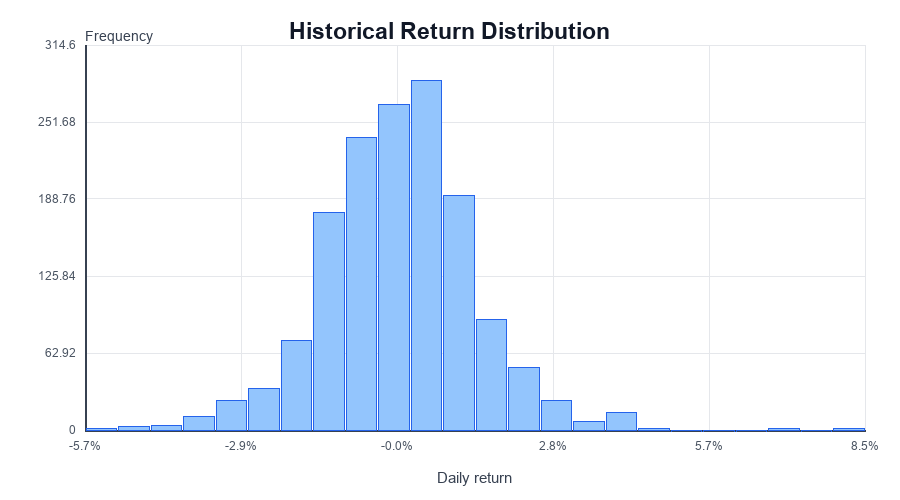


## 11.4 Portfolio VaR

Portfolio VaR must use portfolio volatility, including covariance. It is generally not the weighted average of standalone VaRs.


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [4]:
import numpy as np
from scipy.stats import norm

weights = np.array([0.50, 0.30, 0.20])
volatilities = np.array([0.018, 0.014, 0.010])
correlations = np.array([
    [1.00, 0.55, 0.20],
    [0.55, 1.00, 0.15],
    [0.20, 0.15, 1.00],
])
position = 1_000_000
confidence = 0.99

covariance = np.outer(volatilities, volatilities) * correlations
portfolio_volatility = np.sqrt(weights @ covariance @ weights)
portfolio_var = position * norm.ppf(confidence) * portfolio_volatility
weighted_standalone = position * norm.ppf(confidence) * (weights @ volatilities)

print("Portfolio VaR =", round(float(portfolio_var), 2))
print("Weighted standalone VaR =", round(float(weighted_standalone), 2))
print("Diversification benefit =", round(float(weighted_standalone - portfolio_var), 2))


Portfolio VaR = 28863.59
Weighted standalone VaR = 35360.49
Diversification benefit = 6496.89


**Result interpretation.** Positive but imperfect correlations create a diversification benefit relative to weighted standalone risks.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.
